In [1]:
# CELL 1 - Mount Google Drive and install dependencies
import os
import sys
import subprocess
from pathlib import Path

# Tat torch compile de tranh mot so loi khong can thiet tren Colab.
os.environ["TORCH_COMPILE_DISABLE"] = "1"

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Google Drive mount skipped or failed: {exc}")

REQUIRED_PACKAGES = ["ultralytics", "pandas", "pyyaml", "pillow", "matplotlib", "tqdm"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])

import torch

print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU memory: {total_gb:.2f} GB")
else:
    print("WARNING: GPU is not available. In Colab, set Runtime > Change runtime type > T4 GPU.")


Mounted at /content/drive
Python: 3.12.13
Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [2]:
# CELL 2 - Global configuration
from pathlib import Path

PROJECT_NAME = "school_uniform_yolov8"
IMAGE_DATASET_DIR = Path("/content/drive/MyDrive/DATN2/dataset_images")
LABELS_ALL_DIR = Path("/content/drive/MyDrive/DATN2/labels/all")
OUTPUT_ROOT = Path("/content/drive/MyDrive/DATN2/yolov8_uniform_training_output")
WORK_DIR = Path("/content/uniform_yolo_dataset")
DATA_YAML_PATH = WORK_DIR / "data.yaml"

CLASSES = [
    "ao_so_mi_trang",
    "ao_doan_thanh_nien",
    "quan_tay_dai_den",
    "khan_quang_do",
]

BAD_IDS = {1193, 1194, 2329}
GROUP_RANGES = {
    "group_short_white_shirt": (80, 400),
    "group_long_white_shirt": (1079, 1480),
    "group_youth_union_shirt": (2080, 2880),
}

TRAIN_RATIO = 0.85
VAL_RATIO = 0.15
TEST_RATIO = 0.0
RANDOM_SEED = 42

# Mac dinh an toan cho Colab T4. Co the doi sang "yolov8n.pt" neu thieu VRAM.
MODEL_CHOICE = "yolov8s.pt"
IMG_SIZE = 640
EPOCHS = 200
BATCH_SIZE = 8
WORKERS = 2
PATIENCE = 40
CACHE = False

DRAW_ALL_PREVIEWS = False
PREVIEW_SAMPLES_PER_SPLIT = 6
SAMPLE_PREDICTION_COUNT = 8

print("Configuration loaded")
print(f"Images: {IMAGE_DATASET_DIR}")
print(f"Labels: {LABELS_ALL_DIR}")
print(f"Output: {OUTPUT_ROOT}")
print(f"Classes ({len(CLASSES)}): {CLASSES}")


Configuration loaded
Images: /content/drive/MyDrive/DATN2/dataset_images
Labels: /content/drive/MyDrive/DATN2/labels/all
Output: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output
Classes (4): ['ao_so_mi_trang', 'ao_doan_thanh_nien', 'quan_tay_dai_den', 'khan_quang_do']


In [3]:
# CELL 3 - Dataset scanner and validator
import json
import math
import re
from collections import Counter
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
ID_PATTERN = re.compile(r"_id(\d+)_")
INTEGER_PATTERN = re.compile(r"^[+-]?\d+$")


def extract_image_id(path: Path) -> int | None:
    match = ID_PATTERN.search(path.name)
    return int(match.group(1)) if match else None


def group_name_for_id(image_id: int | None) -> str:
    if image_id is None:
        return "other_valid"
    for group_name, (start_id, end_id) in GROUP_RANGES.items():
        if start_id <= image_id <= end_id:
            return group_name
    return "other_valid"


def iter_image_files(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        raise FileNotFoundError(f"Image folder does not exist: {image_dir}")
    return sorted(path for path in image_dir.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)


def validate_label_file(label_file: Path) -> tuple[bool, list[dict], list[str], bool]:
    try:
        raw_text = label_file.read_text(encoding="utf-8-sig", errors="replace")
    except OSError as exc:
        return False, [], [f"could not read label file: {exc}"], False

    lines = [line.strip() for line in raw_text.splitlines() if line.strip()]
    if not lines:
        return False, [], [], True

    boxes: list[dict] = []
    errors: list[str] = []
    for line_number, line in enumerate(lines, start=1):
        parts = line.split()
        if len(parts) != 5:
            errors.append(f"line {line_number}: expected 5 values, got {len(parts)}")
            continue

        class_token, *coord_tokens = parts
        if not INTEGER_PATTERN.fullmatch(class_token):
            errors.append(f"line {line_number}: class_id is not an integer: {class_token!r}")
            continue

        class_id = int(class_token)
        if class_id < 0 or class_id >= len(CLASSES):
            errors.append(f"line {line_number}: class_id {class_id} outside 0-{len(CLASSES) - 1}")
            continue

        try:
            x_center, y_center, width, height = [float(value) for value in coord_tokens]
        except ValueError:
            errors.append(f"line {line_number}: coordinates are not numeric")
            continue

        coords = (x_center, y_center, width, height)
        if not all(math.isfinite(value) for value in coords):
            errors.append(f"line {line_number}: coordinates must be finite")
            continue
        if not (0.0 <= x_center <= 1.0 and 0.0 <= y_center <= 1.0):
            errors.append(f"line {line_number}: x_center/y_center must be between 0 and 1")
            continue
        if not (0.0 < width <= 1.0 and 0.0 < height <= 1.0):
            errors.append(f"line {line_number}: width/height must be > 0 and <= 1")
            continue

        boxes.append(
            {
                "class_id": class_id,
                "class_name": CLASSES[class_id],
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
            }
        )

    return len(errors) == 0 and len(boxes) > 0, boxes, errors, False


def boxes_to_class_counts(boxes: list[dict]) -> dict[str, int]:
    counts = {class_name: 0 for class_name in CLASSES}
    for box in boxes:
        counts[CLASSES[int(box["class_id"])]] += 1
    return counts


def flatten_validation_record(record: dict) -> dict:
    flat = {key: value for key, value in record.items() if key != "class_counts"}
    class_counts = record.get("class_counts", {})
    for class_index, class_name in enumerate(CLASSES):
        flat[f"class_{class_index}_{class_name}"] = int(class_counts.get(class_name, 0))
    return flat


def scan_and_validate_dataset() -> dict:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    if not LABELS_ALL_DIR.exists():
        raise FileNotFoundError(f"Label folder does not exist: {LABELS_ALL_DIR}")

    image_files = iter_image_files(IMAGE_DATASET_DIR)
    label_files = sorted(path for path in LABELS_ALL_DIR.glob("*.txt") if path.is_file())

    stats = Counter()
    class_instance_counts = {class_name: 0 for class_name in CLASSES}
    validation_records: list[dict] = []
    valid_records: list[dict] = []
    excluded_bad_ids_found: set[int] = set()

    for image_path in tqdm(image_files, desc="Scanning images"):
        image_id = extract_image_id(image_path)

        # Cac ID loi duoc loai bo hoan toan, khong dua vao manifest train/val/test.
        if image_id in BAD_IDS:
            stats["bad_id_excluded"] += 1
            excluded_bad_ids_found.add(int(image_id))
            continue

        label_path = LABELS_ALL_DIR / f"{image_path.stem}.txt"
        group_name = group_name_for_id(image_id)
        base_record = {
            "image_id": image_id,
            "file_name": image_path.name,
            "image_path": str(image_path),
            "label_path": str(label_path) if label_path.exists() else "",
            "group": group_name,
        }

        if not label_path.exists():
            stats["missing_label"] += 1
            validation_records.append(
                {
                    **base_record,
                    "status": "missing_label",
                    "box_count": 0,
                    "errors": "matching label file not found",
                    "class_counts": {class_name: 0 for class_name in CLASSES},
                }
            )
            continue

        is_valid, boxes, errors, is_empty = validate_label_file(label_path)
        if is_empty:
            stats["empty_label"] += 1
            validation_records.append(
                {
                    **base_record,
                    "status": "empty_label",
                    "box_count": 0,
                    "errors": "label file has no non-empty YOLO rows",
                    "class_counts": {class_name: 0 for class_name in CLASSES},
                }
            )
            continue

        if not is_valid:
            stats["invalid_label"] += 1
            validation_records.append(
                {
                    **base_record,
                    "status": "invalid_label",
                    "box_count": len(boxes),
                    "errors": "; ".join(errors),
                    "class_counts": boxes_to_class_counts(boxes),
                }
            )
            continue

        class_counts = boxes_to_class_counts(boxes)
        for class_name, count in class_counts.items():
            class_instance_counts[class_name] += int(count)

        valid_record = {**base_record, "status": "valid", "box_count": len(boxes), "errors": "", "class_counts": class_counts}
        stats["valid"] += 1
        valid_records.append(valid_record)
        validation_records.append(valid_record)

    summary = {
        "project_name": PROJECT_NAME,
        "source_image_count": len(image_files),
        "label_file_count": len(label_files),
        "valid_image_count": len(valid_records),
        "missing_label_count": int(stats["missing_label"]),
        "empty_label_count": int(stats["empty_label"]),
        "invalid_label_count": int(stats["invalid_label"]),
        "bad_id_excluded_count": int(stats["bad_id_excluded"]),
        "excluded_bad_ids_found": sorted(excluded_bad_ids_found),
        "bad_ids_configured": sorted(BAD_IDS),
        "classes": CLASSES,
        "class_instance_counts": class_instance_counts,
    }

    report_json_path = OUTPUT_ROOT / "dataset_validation_report.json"
    report_csv_path = OUTPUT_ROOT / "dataset_validation_report.csv"
    report_json_path.write_text(json.dumps({"summary": summary, "records": validation_records}, indent=2, ensure_ascii=False), encoding="utf-8")
    pd.DataFrame([flatten_validation_record(record) for record in validation_records]).to_csv(report_csv_path, index=False, encoding="utf-8-sig")

    print("Dataset validation report")
    print(f"  Source images found: {summary['source_image_count']}")
    print(f"  Label files found: {summary['label_file_count']}")
    print(f"  Valid images used: {summary['valid_image_count']}")
    print(f"  Missing labels: {summary['missing_label_count']}")
    print(f"  Empty labels: {summary['empty_label_count']}")
    print(f"  Invalid labels: {summary['invalid_label_count']}")
    print(f"  Excluded bad IDs found: {summary['excluded_bad_ids_found']}")
    print("  Class instances:")
    for class_name, count in class_instance_counts.items():
        print(f"    {class_name}: {count}")
    print(f"Saved JSON: {report_json_path}")
    print(f"Saved CSV: {report_csv_path}")

    return {"summary": summary, "valid_records": valid_records, "validation_records": validation_records}


SCAN_RESULT = scan_and_validate_dataset()
VALID_RECORDS = SCAN_RESULT["valid_records"]
if not VALID_RECORDS:
    raise RuntimeError("No valid labeled images were found. Stop and check dataset paths/labels.")


Scanning images:   0%|          | 0/1524 [00:00<?, ?it/s]

Dataset validation report
  Source images found: 1524
  Label files found: 1524
  Valid images used: 1490
  Missing labels: 0
  Empty labels: 31
  Invalid labels: 0
  Excluded bad IDs found: [1193, 1194, 2329]
  Class instances:
    ao_so_mi_trang: 721
    ao_doan_thanh_nien: 741
    quan_tay_dai_den: 1424
    khan_quang_do: 689
Saved JSON: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/dataset_validation_report.json
Saved CSV: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/dataset_validation_report.csv


In [4]:
# CELL 4 - Build train/val/test split
import random
from collections import defaultdict


def split_group_records(records: list[dict], group_index: int) -> dict[str, list[dict]]:
    records = sorted(records, key=lambda record: (record["image_id"] is None, record["image_id"] or -1, record["file_name"]))
    rng = random.Random(RANDOM_SEED + group_index)
    shuffled = records[:]
    rng.shuffle(shuffled)

    n_total = len(shuffled)
    if n_total == 0:
        return {"train": [], "val": [], "test": []}

    n_test = int(round(n_total * TEST_RATIO)) if TEST_RATIO > 0 else 0
    n_test = min(n_test, max(0, n_total - 1))
    n_train = int(round(n_total * TRAIN_RATIO))
    n_train = min(n_train, n_total - n_test)
    if n_total - n_test > 1 and n_train >= n_total - n_test:
        n_train = n_total - n_test - 1
    n_train = max(1, n_train) if n_total - n_test > 0 else 0

    train_records = shuffled[:n_train]
    remaining = shuffled[n_train:]
    test_records = remaining[-n_test:] if n_test else []
    val_records = remaining[:-n_test] if n_test else remaining
    return {"train": train_records, "val": val_records, "test": test_records}


GROUPED_RECORDS: dict[str, list[dict]] = defaultdict(list)
for record in VALID_RECORDS:
    GROUPED_RECORDS[record["group"]].append(record)
for expected_group in [*GROUP_RANGES.keys(), "other_valid"]:
    GROUPED_RECORDS.setdefault(expected_group, [])

SPLITS = {"train": [], "val": [], "test": []}
GROUP_SPLIT_COUNTS: list[dict] = []
for group_index, group_name in enumerate([*GROUP_RANGES.keys(), "other_valid"]):
    group_records = GROUPED_RECORDS[group_name]
    group_split = split_group_records(group_records, group_index)
    for split_name, split_records in group_split.items():
        SPLITS[split_name].extend(split_records)
    GROUP_SPLIT_COUNTS.append(
        {"group": group_name, "total": len(group_records), "train": len(group_split["train"]), "val": len(group_split["val"]), "test": len(group_split["test"])}
    )

if GROUPED_RECORDS["other_valid"]:
    print("WARNING: Valid images outside the expected ID ranges were found and split as 'other_valid'.")

all_split_ids = [record["image_id"] for split_records in SPLITS.values() for record in split_records]
bad_ids_in_split = sorted(image_id for image_id in all_split_ids if image_id in BAD_IDS)
if bad_ids_in_split:
    raise RuntimeError(f"Bad IDs leaked into split: {bad_ids_in_split}")

print("Grouped split summary")
for row in GROUP_SPLIT_COUNTS:
    print(f"  {row['group']}: total={row['total']}, train={row['train']}, val={row['val']}, test={row['test']}")
print(f"Total train images: {len(SPLITS['train'])}")
print(f"Total val images: {len(SPLITS['val'])}")
print(f"Total test images: {len(SPLITS['test'])}")


Grouped split summary
  group_short_white_shirt: total=321, train=273, val=48, test=0
  group_long_white_shirt: total=400, train=340, val=60, test=0
  group_youth_union_shirt: total=769, train=654, val=115, test=0
  other_valid: total=0, train=0, val=0, test=0
Total train images: 1267
Total val images: 223
Total test images: 0


In [5]:
# CELL 5 - Create YOLOv8 dataset structure
import shutil
import yaml


def ensure_safe_work_dir(path: Path) -> None:
    resolved = path.resolve()
    if str(resolved) in {"/", "/content", "/content/drive"}:
        raise RuntimeError(f"Refusing to clean unsafe work directory: {resolved}")
    if not str(resolved).startswith("/content/"):
        raise RuntimeError(f"WORK_DIR must stay under /content on Colab: {resolved}")


ensure_safe_work_dir(WORK_DIR)
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for split_name in ["train", "val", "test"]:
    (WORK_DIR / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (WORK_DIR / "labels" / split_name).mkdir(parents=True, exist_ok=True)

COPIED_MANIFEST: list[dict] = []
for split_name, records in SPLITS.items():
    txt_lines: list[str] = []
    for record in records:
        source_image = Path(record["image_path"])
        source_label = Path(record["label_path"])
        if not source_image.exists():
            raise FileNotFoundError(f"Missing source image during copy: {source_image}")
        if not source_label.exists():
            raise FileNotFoundError(f"Missing source label during copy: {source_label}")

        target_image = WORK_DIR / "images" / split_name / source_image.name
        target_label = WORK_DIR / "labels" / split_name / source_label.name
        shutil.copy2(source_image, target_image)
        shutil.copy2(source_label, target_label)
        txt_lines.append(str(target_image))
        COPIED_MANIFEST.append(
            {
                "split": split_name,
                "image_id": record["image_id"],
                "group": record["group"],
                "source_image": str(source_image),
                "source_label": str(source_label),
                "target_image": str(target_image),
                "target_label": str(target_label),
                "box_count": record["box_count"],
            }
        )
    (WORK_DIR / f"{split_name}.txt").write_text("\n".join(txt_lines) + ("\n" if txt_lines else ""), encoding="utf-8")

(WORK_DIR / "classes.txt").write_text("\n".join(CLASSES) + "\n", encoding="utf-8")
data_yaml = {
    "path": str(WORK_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASSES),
    "names": {index: class_name for index, class_name in enumerate(CLASSES)},
}
DATA_YAML_PATH.write_text(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True), encoding="utf-8")

print(f"YOLOv8 dataset created at: {WORK_DIR}")
print(f"data.yaml: {DATA_YAML_PATH}")
print(DATA_YAML_PATH.read_text(encoding="utf-8"))


YOLOv8 dataset created at: /content/uniform_yolo_dataset
data.yaml: /content/uniform_yolo_dataset/data.yaml
path: /content/uniform_yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 4
names:
  0: ao_so_mi_trang
  1: ao_doan_thanh_nien
  2: quan_tay_dai_den
  3: khan_quang_do



Dataset summary
  Total source images found: 1524
  Total valid images used: 1490
  Train image count: 1267
  Val image count: 223
  Test image count: 0
  Excluded bad IDs found: [1193, 1194, 2329]
  Missing label count: 0
  Empty label count: 31
  Invalid label count: 0

Split summary:
split  images  labels  instances
train    1267    1267       3044
  val     223     223        531
 test       0       0          0

Class distribution:
split  class_id         class_name  instances
train         0     ao_so_mi_trang        613
train         1 ao_doan_thanh_nien        631
train         2   quan_tay_dai_den       1213
train         3      khan_quang_do        587
  val         0     ao_so_mi_trang        108
  val         1 ao_doan_thanh_nien        110
  val         2   quan_tay_dai_den        211
  val         3      khan_quang_do        102
 test         0     ao_so_mi_trang          0
 test         1 ao_doan_thanh_nien          0
 test         2   quan_tay_dai_den          0
 test  

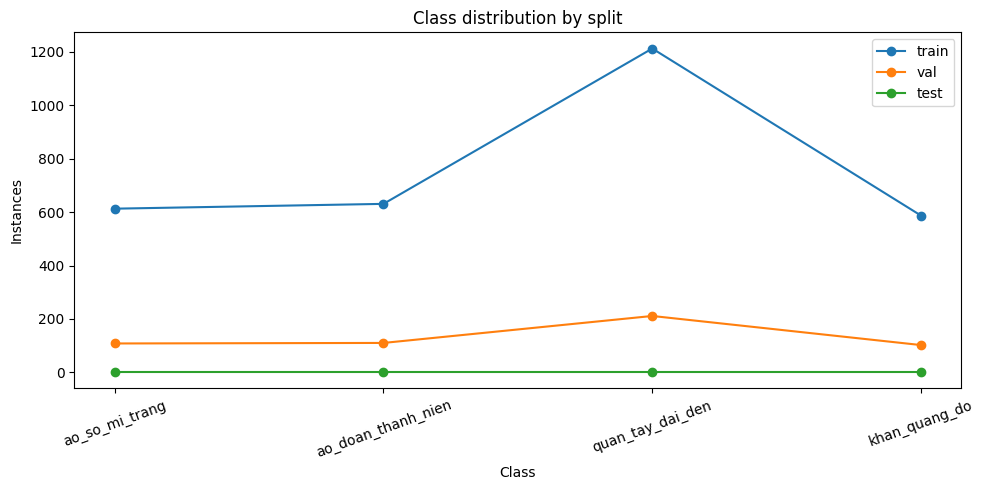

Saved split summary: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/split_summary.csv
Saved class distribution: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/class_distribution.csv
Saved split manifest: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/split_manifest.csv
Saved class distribution plot: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/class_distribution.png


In [6]:
# CELL 6 - Dataset summary and visualization
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd


def count_instances_in_label(label_path: Path) -> Counter:
    counts = Counter()
    for line in label_path.read_text(encoding="utf-8-sig", errors="replace").splitlines():
        line = line.strip()
        if not line:
            continue
        counts[int(line.split()[0])] += 1
    return counts


SPLIT_CLASS_COUNTS: dict[str, Counter] = {split_name: Counter() for split_name in ["train", "val", "test"]}
for split_name in SPLIT_CLASS_COUNTS:
    for label_path in sorted((WORK_DIR / "labels" / split_name).glob("*.txt")):
        SPLIT_CLASS_COUNTS[split_name].update(count_instances_in_label(label_path))

split_summary_rows = []
for split_name in ["train", "val", "test"]:
    image_count = len(list((WORK_DIR / "images" / split_name).glob("*")))
    label_count = len(list((WORK_DIR / "labels" / split_name).glob("*.txt")))
    instance_count = sum(SPLIT_CLASS_COUNTS[split_name].values())
    split_summary_rows.append({"split": split_name, "images": image_count, "labels": label_count, "instances": instance_count})

class_distribution_rows = []
for split_name, counter in SPLIT_CLASS_COUNTS.items():
    for class_id, class_name in enumerate(CLASSES):
        class_distribution_rows.append({"split": split_name, "class_id": class_id, "class_name": class_name, "instances": int(counter.get(class_id, 0))})

split_manifest_rows = []
for split_name, records in SPLITS.items():
    for record in records:
        split_manifest_rows.append(
            {
                "split": split_name,
                "image_id": record["image_id"],
                "group": record["group"],
                "file_name": record["file_name"],
                "source_image": record["image_path"],
                "source_label": record["label_path"],
                "box_count": record["box_count"],
            }
        )

for bad_id in BAD_IDS:
    if bad_id in {row["image_id"] for row in split_manifest_rows}:
        raise RuntimeError(f"Bad ID {bad_id} is present in split_manifest.csv")

split_summary_path = OUTPUT_ROOT / "split_summary.csv"
class_distribution_path = OUTPUT_ROOT / "class_distribution.csv"
split_manifest_path = OUTPUT_ROOT / "split_manifest.csv"
pd.DataFrame(split_summary_rows).to_csv(split_summary_path, index=False, encoding="utf-8-sig")
pd.DataFrame(class_distribution_rows).to_csv(class_distribution_path, index=False, encoding="utf-8-sig")
pd.DataFrame(split_manifest_rows).to_csv(split_manifest_path, index=False, encoding="utf-8-sig")

print("Dataset summary")
print(f"  Total source images found: {SCAN_RESULT['summary']['source_image_count']}")
print(f"  Total valid images used: {SCAN_RESULT['summary']['valid_image_count']}")
print(f"  Train image count: {len(SPLITS['train'])}")
print(f"  Val image count: {len(SPLITS['val'])}")
print(f"  Test image count: {len(SPLITS['test'])}")
print(f"  Excluded bad IDs found: {SCAN_RESULT['summary']['excluded_bad_ids_found']}")
print(f"  Missing label count: {SCAN_RESULT['summary']['missing_label_count']}")
print(f"  Empty label count: {SCAN_RESULT['summary']['empty_label_count']}")
print(f"  Invalid label count: {SCAN_RESULT['summary']['invalid_label_count']}")
print("\nSplit summary:")
print(pd.DataFrame(split_summary_rows).to_string(index=False))
print("\nClass distribution:")
print(pd.DataFrame(class_distribution_rows).to_string(index=False))

plot_df = pd.DataFrame(class_distribution_rows)
fig, ax = plt.subplots(figsize=(10, 5))
for split_name in ["train", "val", "test"]:
    split_df = plot_df[plot_df["split"] == split_name]
    ax.plot(split_df["class_name"], split_df["instances"], marker="o", label=split_name)
ax.set_title("Class distribution by split")
ax.set_xlabel("Class")
ax.set_ylabel("Instances")
ax.tick_params(axis="x", rotation=20)
ax.legend()
fig.tight_layout()
class_distribution_plot_path = OUTPUT_ROOT / "class_distribution.png"
fig.savefig(class_distribution_plot_path, dpi=160)
plt.show()

print(f"Saved split summary: {split_summary_path}")
print(f"Saved class distribution: {class_distribution_path}")
print(f"Saved split manifest: {split_manifest_path}")
print(f"Saved class distribution plot: {class_distribution_plot_path}")


In [7]:
# CELL 7 - Optional draw bbox previews
import random

from PIL import Image, ImageDraw, ImageFont

CLASS_COLORS = [(0, 174, 239), (34, 197, 94), (245, 158, 11), (239, 68, 68)]


def yolo_to_xyxy(box: list[float], image_width: int, image_height: int) -> tuple[int, int, int, int]:
    x_center, y_center, width, height = box
    x_min = int(round((x_center - width / 2.0) * image_width))
    y_min = int(round((y_center - height / 2.0) * image_height))
    x_max = int(round((x_center + width / 2.0) * image_width))
    y_max = int(round((y_center + height / 2.0) * image_height))
    return (
        max(0, min(image_width - 1, x_min)),
        max(0, min(image_height - 1, y_min)),
        max(0, min(image_width - 1, x_max)),
        max(0, min(image_height - 1, y_max)),
    )


def draw_preview_image(image_path: Path, label_path: Path, output_path: Path) -> None:
    with Image.open(image_path) as original:
        image = original.convert("RGB")
        width, height = image.size
        draw = ImageDraw.Draw(image)
        font = ImageFont.load_default()
        line_width = max(2, min(8, round(min(width, height) / 220)))

        for line in label_path.read_text(encoding="utf-8-sig", errors="replace").splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            coords = [float(value) for value in parts[1:]]
            x_min, y_min, x_max, y_max = yolo_to_xyxy(coords, width, height)
            color = CLASS_COLORS[class_id % len(CLASS_COLORS)]
            for offset in range(line_width):
                draw.rectangle((x_min - offset, y_min - offset, x_max + offset, y_max + offset), outline=color)
            label = CLASSES[class_id]
            text_box = draw.textbbox((0, 0), label, font=font)
            text_width = text_box[2] - text_box[0]
            text_height = text_box[3] - text_box[1]
            text_y = max(0, y_min - text_height - 6)
            draw.rectangle((x_min, text_y, x_min + text_width + 8, text_y + text_height + 6), fill=color)
            draw.text((x_min + 4, text_y + 3), label, fill=(255, 255, 255), font=font)

        output_path.parent.mkdir(parents=True, exist_ok=True)
        image.save(output_path, quality=95)


preview_root = OUTPUT_ROOT / "bbox_preview_samples"
if preview_root.exists():
    shutil.rmtree(preview_root)
preview_root.mkdir(parents=True, exist_ok=True)

rng = random.Random(RANDOM_SEED)
created_previews = []
for split_name in ["train", "val", "test"]:
    split_images = sorted((WORK_DIR / "images" / split_name).glob("*"))
    if not split_images:
        continue
    selected_images = split_images if DRAW_ALL_PREVIEWS else rng.sample(split_images, min(PREVIEW_SAMPLES_PER_SPLIT, len(split_images)))
    for image_path in selected_images:
        label_path = WORK_DIR / "labels" / split_name / f"{image_path.stem}.txt"
        output_path = preview_root / split_name / image_path.name
        draw_preview_image(image_path, label_path, output_path)
        created_previews.append(output_path)

print(f"Created {len(created_previews)} bbox preview images")
print(f"Preview folder: {preview_root}")


Created 12 bbox preview images
Preview folder: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/bbox_preview_samples


In [8]:
# CELL 8 - Train YOLOv8
from pathlib import Path

from ultralytics import YOLO

if not DATA_YAML_PATH.exists():
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML_PATH}")

RUN_NAME = f"train_uniform_{Path(str(MODEL_CHOICE)).stem}".replace(".", "_")
print(f"Training model: {MODEL_CHOICE}")
print(f"Run name: {RUN_NAME}")

model = YOLO(MODEL_CHOICE)
TRAIN_RESULTS = model.train(
    data=str(DATA_YAML_PATH),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    project=str(OUTPUT_ROOT / "runs"),
    name=RUN_NAME,
    exist_ok=True,
    cache=CACHE,
    optimizer="auto",
    cos_lr=True,
    close_mosaic=10,
    seed=RANDOM_SEED,
    deterministic=True,
    pretrained=str(MODEL_CHOICE).endswith(".pt"),
    plots=True,
    val=True,
    fliplr=0.5,
    flipud=0.0,
    degrees=7.0,
    translate=0.10,
    scale=0.40,
    shear=0.0,
    perspective=0.0005,
    hsv_h=0.015,
    hsv_s=0.50,
    hsv_v=0.35,
    mosaic=1.0,
)

RUN_DIR = Path(getattr(TRAIN_RESULTS, "save_dir", OUTPUT_ROOT / "runs" / RUN_NAME))
print(f"Training finished. Run directory: {RUN_DIR}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Training model: yolov8s.pt
Run name: train_uniform_yolov8s
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/uniform_yolo_dataset/data.yaml, degrees=7.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction

In [9]:
# CELL 9 - Validate best model
import json
from pathlib import Path

from ultralytics import YOLO


def latest_best_pt(output_root: Path) -> Path | None:
    candidates = sorted((output_root / "runs").glob("**/weights/best.pt"), key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def jsonable(value):
    if hasattr(value, "item"):
        return value.item()
    if isinstance(value, dict):
        return {str(key): jsonable(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(item) for item in value]
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


if "RUN_DIR" not in globals() or not Path(RUN_DIR).exists():
    BEST_PT = latest_best_pt(OUTPUT_ROOT)
    if BEST_PT is None:
        raise FileNotFoundError("best.pt was not found. Run the training cell first.")
    RUN_DIR = BEST_PT.parents[1]
else:
    RUN_DIR = Path(RUN_DIR)
    BEST_PT = RUN_DIR / "weights" / "best.pt"

LAST_PT = RUN_DIR / "weights" / "last.pt"
if not BEST_PT.exists():
    raise FileNotFoundError(f"best.pt not found: {BEST_PT}")
if not LAST_PT.exists():
    raise FileNotFoundError(f"last.pt not found: {LAST_PT}")

best_model = YOLO(str(BEST_PT))
VAL_RESULTS = best_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    project=str(OUTPUT_ROOT / "runs"),
    name="val_best_uniform_yolov8",
    exist_ok=True,
)

metrics = jsonable(getattr(VAL_RESULTS, "results_dict", {}))
validation_metrics_path = OUTPUT_ROOT / "validation_metrics.json"
validation_metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"best.pt: {BEST_PT}")
print(f"last.pt: {LAST_PT}")
print(f"Validation metrics JSON: {validation_metrics_path}")
print(metrics)


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3463.4±524.5 MB/s, size: 415.4 KB)
val: Scanning /content/uniform_yolo_dataset/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 77.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 4.5it/s 6.2s
                   all        223        531      0.878      0.898       0.92      0.558
        ao_so_mi_trang        108        108      0.924      0.935      0.958      0.568
    ao_doan_thanh_nien        110        110      0.892        0.9      0.932      0.571
      quan_tay_dai_den        211        211      0.981      0.989      0.992      0.671
         khan_quang_do        102        102      0.717      0.768        0.8      0.422
Speed: 1.9ms preprocess, 8.3ms infe

In [10]:
# CELL 10 - Test inference on sample images
from pathlib import Path

from ultralytics import YOLO

if "BEST_PT" not in globals() or not Path(BEST_PT).exists():
    raise FileNotFoundError("BEST_PT is not available. Run Cell 9 first.")

sample_sources = sorted((WORK_DIR / "images" / "val").glob("*"))
if not sample_sources:
    sample_sources = sorted((WORK_DIR / "images" / "train").glob("*"))
if not sample_sources:
    raise RuntimeError("No sample images available for prediction.")

sample_sources = sample_sources[:SAMPLE_PREDICTION_COUNT]
predict_model = YOLO(str(BEST_PT))
PREDICTION_RESULTS = predict_model.predict(
    source=[str(path) for path in sample_sources],
    conf=0.25,
    imgsz=IMG_SIZE,
    save=True,
    project=str(OUTPUT_ROOT),
    name="sample_predictions",
    exist_ok=True,
)

SAMPLE_PREDICTIONS_DIR = Path(getattr(PREDICTION_RESULTS[0], "save_dir", OUTPUT_ROOT / "sample_predictions")) if PREDICTION_RESULTS else OUTPUT_ROOT / "sample_predictions"

for result in PREDICTION_RESULTS:
    print(f"Image: {getattr(result, 'path', '')}")
    if result.boxes is None or len(result.boxes) == 0:
        print("  No detections")
        continue
    for box in result.boxes:
        class_id = int(box.cls.detach().cpu().item())
        confidence = float(box.conf.detach().cpu().item())
        xyxy = [round(float(value), 2) for value in box.xyxy[0].detach().cpu().tolist()]
        print(f"  {CLASSES[class_id]} conf={confidence:.3f} box={xyxy}")

print(f"Sample predictions saved to: {SAMPLE_PREDICTIONS_DIR}")



0: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
1: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 1 khan_quang_do, 8.0ms
2: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
3: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
4: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
5: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
6: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 2 khan_quang_dos, 8.0ms
7: 640x384 1 ao_so_mi_trang, 1 quan_tay_dai_den, 1 khan_quang_do, 8.0ms
Speed: 2.3ms preprocess, 8.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/sample_predictions
Image: image0.jpg
  quan_tay_dai_den conf=0.864 box=[245.7, 777.02, 678.11, 1644.74]
  ao_so_mi_trang conf=0.787 box=[177.32, 245.54, 737.07, 872.66]
  khan_quang_do conf=0.477 box=[267.41, 211.12, 541.96, 615.0]
  khan_quang

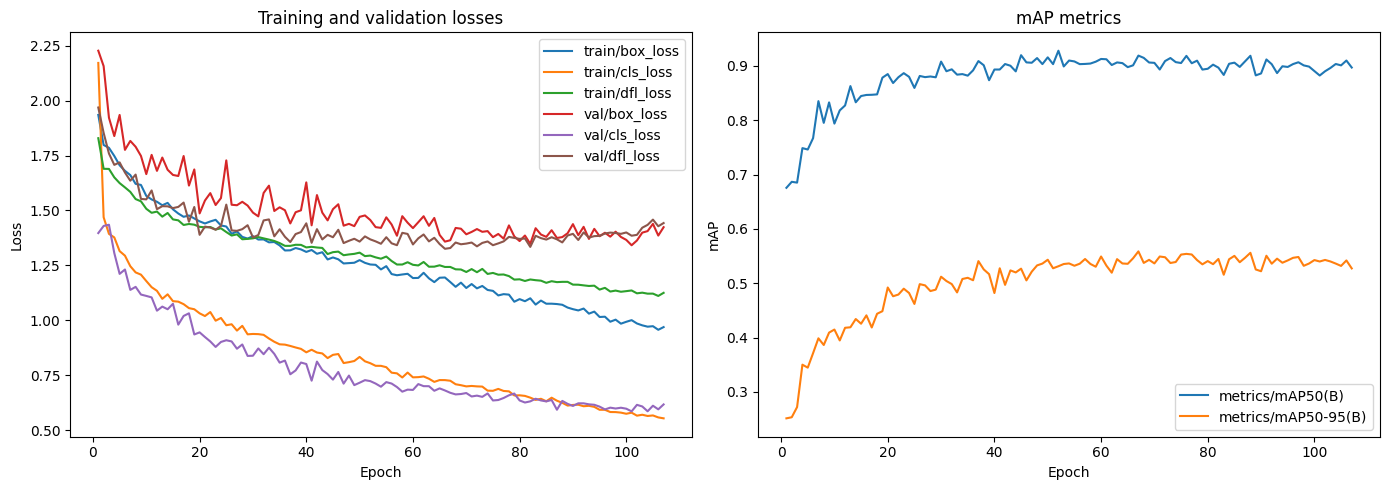

Saved training curves: /content/drive/MyDrive/DATN2/yolov8_uniform_training_output/training_curves.png


In [11]:
# CELL 11 - Plot training results
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "RUN_DIR" not in globals() or not Path(RUN_DIR).exists():
    best_candidates = sorted((OUTPUT_ROOT / "runs").glob("**/weights/best.pt"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not best_candidates:
        raise FileNotFoundError("No YOLO run directory found. Run training first.")
    RUN_DIR = best_candidates[0].parents[1]
else:
    RUN_DIR = Path(RUN_DIR)

results_csv_path = RUN_DIR / "results.csv"
if not results_csv_path.exists():
    print(f"results.csv not found: {results_csv_path}")
else:
    results_df = pd.read_csv(results_csv_path)
    results_df.columns = [column.strip() for column in results_df.columns]
    x_values = results_df["epoch"] if "epoch" in results_df.columns else results_df.index
    train_loss_cols = [column for column in results_df.columns if column.startswith("train/") and column.endswith("_loss")]
    val_loss_cols = [column for column in results_df.columns if column.startswith("val/") and column.endswith("_loss")]
    map_cols = [column for column in results_df.columns if "mAP" in column or "map" in column]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if train_loss_cols or val_loss_cols:
        for column in train_loss_cols + val_loss_cols:
            axes[0].plot(x_values, results_df[column], label=column)
        axes[0].set_title("Training and validation losses")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, "No loss columns found", ha="center", va="center")
        axes[0].set_axis_off()

    if map_cols:
        for column in map_cols:
            axes[1].plot(x_values, results_df[column], label=column)
        axes[1].set_title("mAP metrics")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("mAP")
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "No mAP columns found", ha="center", va="center")
        axes[1].set_axis_off()

    fig.tight_layout()
    TRAINING_CURVES_PATH = OUTPUT_ROOT / "training_curves.png"
    fig.savefig(TRAINING_CURVES_PATH, dpi=180)
    plt.show()
    print(f"Saved training curves: {TRAINING_CURVES_PATH}")


In [12]:
# CELL 12 - Export Windows 11 deployment package and auto-download
import json
import shutil
import zipfile
from datetime import datetime
from pathlib import Path

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ZIP_PATH = Path("/content/drive/MyDrive/DATN2/yolov8_uniform_windows_package.zip")
PACKAGE_ROOT = OUTPUT_ROOT / "windows_package_tmp"

if PACKAGE_ROOT.exists():
    shutil.rmtree(PACKAGE_ROOT)
PACKAGE_ROOT.mkdir(parents=True, exist_ok=True)


def existing_path(value) -> Path | None:
    if value is None:
        return None
    path = Path(value)
    return path if path.exists() else None


def locate_latest_run_dir_for_package() -> Path | None:
    candidates = sorted((OUTPUT_ROOT / "runs").glob("**/weights/best.pt"), key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0].parents[1] if candidates else None


RUN_DIR_FOR_PACKAGE = existing_path(globals().get("RUN_DIR")) or locate_latest_run_dir_for_package()
if RUN_DIR_FOR_PACKAGE is None:
    raise FileNotFoundError("No training run folder with weights/best.pt was found. Run training before packaging.")

BEST_PT_FOR_PACKAGE = existing_path(globals().get("BEST_PT")) or existing_path(RUN_DIR_FOR_PACKAGE / "weights" / "best.pt")
LAST_PT_FOR_PACKAGE = existing_path(globals().get("LAST_PT")) or existing_path(RUN_DIR_FOR_PACKAGE / "weights" / "last.pt")
if BEST_PT_FOR_PACKAGE is None:
    raise FileNotFoundError("best.pt not found. Run training before packaging.")
if LAST_PT_FOR_PACKAGE is None:
    raise FileNotFoundError("last.pt not found. Run training before packaging.")

copied_files: list[dict] = []
skipped_optional_files: list[str] = []


def safe_copy_file(source: Path | None, relative_target: str, required: bool = False) -> bool:
    if source is None or not Path(source).exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {source}")
        skipped_optional_files.append(str(source))
        return False
    source = Path(source)
    target = PACKAGE_ROOT / relative_target
    target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, target)
    copied_files.append({"source": str(source), "package_path": str(target.relative_to(PACKAGE_ROOT))})
    return True


safe_copy_file(BEST_PT_FOR_PACKAGE, "best.pt", required=True)
safe_copy_file(LAST_PT_FOR_PACKAGE, "last.pt", required=True)

if DATA_YAML_PATH.exists():
    safe_copy_file(DATA_YAML_PATH, "data.yaml", required=True)
else:
    fallback_yaml = "path: .\ntrain: images/train\nval: images/val\ntest: images/test\nnc: 4\nnames:\n  0: ao_so_mi_trang\n  1: ao_doan_thanh_nien\n  2: quan_tay_dai_den\n  3: khan_quang_do\n"
    (PACKAGE_ROOT / "data.yaml").write_text(fallback_yaml, encoding="utf-8")
    copied_files.append({"source": "generated fallback", "package_path": "data.yaml"})

(PACKAGE_ROOT / "classes.txt").write_text("\n".join(CLASSES) + "\n", encoding="utf-8")
(PACKAGE_ROOT / "class_names.json").write_text(json.dumps({index: name for index, name in enumerate(CLASSES)}, indent=2, ensure_ascii=False), encoding="utf-8")
copied_files.extend(
    [
        {"source": "generated", "package_path": "classes.txt"},
        {"source": "generated", "package_path": "class_names.json"},
    ]
)

for filename in [
    "results.csv",
    "args.yaml",
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "labels.jpg",
]:
    safe_copy_file(RUN_DIR_FOR_PACKAGE / filename, f"training_outputs/{filename}")

for pattern in ["train_batch*.jpg", "val_batch*.jpg"]:
    for image_path in sorted(RUN_DIR_FOR_PACKAGE.glob(pattern)):
        safe_copy_file(image_path, f"training_outputs/{image_path.name}")

for filename in [
    "dataset_validation_report.json",
    "dataset_validation_report.csv",
    "split_summary.csv",
    "class_distribution.csv",
    "split_manifest.csv",
    "validation_metrics.json",
    "training_curves.png",
    "class_distribution.png",
]:
    safe_copy_file(OUTPUT_ROOT / filename, f"reports/{filename}")

infer_windows_py = """from __future__ import annotations

import argparse
from pathlib import Path

from ultralytics import YOLO


def parse_source(value: str):
    return int(value) if value.isdigit() else value


def main() -> int:
    parser = argparse.ArgumentParser(description="Run school-uniform YOLOv8 inference on Windows 11.")
    parser.add_argument("--source", required=True, help="Image, video, folder, or webcam index such as 0.")
    parser.add_argument("--weights", default="best.pt", help="Path to model weights. Default: best.pt in this folder.")
    parser.add_argument("--conf", type=float, default=0.25, help="Confidence threshold.")
    parser.add_argument("--imgsz", type=int, default=640, help="Inference image size.")
    parser.add_argument("--output", default="runs_uniform_predict", help="Output folder for annotated predictions.")
    args = parser.parse_args()

    package_dir = Path(__file__).resolve().parent
    weights_path = Path(args.weights)
    if not weights_path.is_absolute():
        weights_path = package_dir / weights_path
    if not weights_path.exists():
        raise FileNotFoundError(f"Weights not found: {weights_path}")

    model = YOLO(str(weights_path))
    results = model.predict(source=parse_source(args.source), conf=args.conf, imgsz=args.imgsz, save=True, project=args.output, name="predict", exist_ok=True)

    for result in results:
        print(f"Source: {getattr(result, 'path', args.source)}")
        if result.boxes is None or len(result.boxes) == 0:
            print("  No detections")
            continue
        for box in result.boxes:
            class_id = int(box.cls.detach().cpu().item())
            confidence = float(box.conf.detach().cpu().item())
            class_name = result.names.get(class_id, str(class_id))
            xyxy = [round(float(value), 2) for value in box.xyxy[0].detach().cpu().tolist()]
            print(f"  {class_name}: conf={confidence:.3f}, box_xyxy={xyxy}")

    if results:
        print(f"Annotated outputs saved to: {results[0].save_dir}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())
"""

requirements_windows_txt = """ultralytics
opencv-python
pillow
numpy
"""

run_example_windows_bat = """@echo off
REM Example: predict one image
python infer_windows.py --source test.jpg --weights best.pt --conf 0.25

REM Example: predict from webcam index 0
python infer_windows.py --source 0 --weights best.pt --conf 0.25
pause
"""

readme_windows_txt = """HUONG DAN CHAY MO HINH YOLOV8 DONG PHUC TREN WINDOWS 11

1. Cai Python
- Cai Python 3.11 tu trang chinh thuc: https://www.python.org/downloads/
- Khi cai dat, chon "Add python.exe to PATH".

2. Mo thu muc goi mo hinh
- Giai nen file yolov8_uniform_windows_package.zip.
- Mo CMD hoac PowerShell tai dung thu muc da giai nen.

3. Cai thu vien
pip install -r requirements_windows.txt

4. Du doan tren anh
python infer_windows.py --source test.jpg --weights best.pt --conf 0.25

Anh da ve bounding box se duoc luu trong thu muc runs_uniform_predict.

5. Du doan bang webcam
python infer_windows.py --source 0 --weights best.pt --conf 0.25

6. Y nghia file weight
- best.pt: mo hinh tot nhat theo metric validation trong qua trinh train. Nen dung file nay de suy luan.
- last.pt: mo hinh tai epoch cuoi cung. Dung de tiep tuc train hoac kiem tra khi can.

7. Bon lop cua bai toan
0: ao_so_mi_trang       = ao so mi trang
1: ao_doan_thanh_nien   = ao Doan Thanh nien mau xanh
2: quan_tay_dai_den     = quan tay dai den
3: khan_quang_do        = khan quang do

8. Vi du nguon du lieu ho tro
- Anh don le: python infer_windows.py --source test.jpg --weights best.pt
- Thu muc anh: python infer_windows.py --source path/to/images --weights best.pt
- Video: python infer_windows.py --source video.mp4 --weights best.pt
- Webcam: python infer_windows.py --source 0 --weights best.pt
"""

(PACKAGE_ROOT / "infer_windows.py").write_text(infer_windows_py, encoding="utf-8")
(PACKAGE_ROOT / "requirements_windows.txt").write_text(requirements_windows_txt, encoding="utf-8")
(PACKAGE_ROOT / "run_example_windows.bat").write_text(run_example_windows_bat, encoding="utf-8")
(PACKAGE_ROOT / "README_WINDOWS_11.txt").write_text(readme_windows_txt, encoding="utf-8")
copied_files.extend(
    [
        {"source": "generated", "package_path": "infer_windows.py"},
        {"source": "generated", "package_path": "requirements_windows.txt"},
        {"source": "generated", "package_path": "run_example_windows.bat"},
        {"source": "generated", "package_path": "README_WINDOWS_11.txt"},
    ]
)

sample_prediction_candidates = [existing_path(globals().get("SAMPLE_PREDICTIONS_DIR")), OUTPUT_ROOT / "sample_predictions"]
for candidate in sample_prediction_candidates:
    if candidate and candidate.exists():
        target_dir = PACKAGE_ROOT / "sample_predictions"
        shutil.copytree(candidate, target_dir, dirs_exist_ok=True)
        for file_path in sorted(target_dir.rglob("*")):
            if file_path.is_file():
                copied_files.append({"source": str(candidate), "package_path": str(file_path.relative_to(PACKAGE_ROOT))})
        break

for notebook_candidate in [Path("/content/Train_uniform_AI_YOLOv8.ipynb"), Path("/content/drive/MyDrive/DATN2/Train_uniform_AI_YOLOv8.ipynb")]:
    if notebook_candidate.exists():
        safe_copy_file(notebook_candidate, "Train_uniform_AI_YOLOv8.ipynb")
        break

package_manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project_name": PROJECT_NAME,
    "classes": {index: name for index, name in enumerate(CLASSES)},
    "bad_ids_excluded": sorted(BAD_IDS),
    "run_dir": str(RUN_DIR_FOR_PACKAGE),
    "best_pt_source": str(BEST_PT_FOR_PACKAGE),
    "last_pt_source": str(LAST_PT_FOR_PACKAGE),
    "copied_files": copied_files,
    "skipped_optional_files": skipped_optional_files,
}
(PACKAGE_ROOT / "package_manifest.json").write_text(json.dumps(package_manifest, indent=2, ensure_ascii=False), encoding="utf-8")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zip_file:
    for file_path in sorted(PACKAGE_ROOT.rglob("*")):
        if file_path.is_file():
            zip_file.write(file_path, arcname=str(file_path.relative_to(PACKAGE_ROOT)))

if not ZIP_PATH.exists() or ZIP_PATH.suffix.lower() != ".zip":
    raise RuntimeError(f"Package zip was not created correctly: {ZIP_PATH}")

print(f"Windows package created: {ZIP_PATH}")
print(f"Package size: {ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB")
print("Included files:")
for item in copied_files:
    print(f"  - {item['package_path']}")

from google.colab import files
files.download("/content/drive/MyDrive/DATN2/yolov8_uniform_windows_package.zip")


Windows package created: /content/drive/MyDrive/DATN2/yolov8_uniform_windows_package.zip
Package size: 48.22 MB
Included files:
  - best.pt
  - last.pt
  - data.yaml
  - classes.txt
  - class_names.json
  - training_outputs/results.csv
  - training_outputs/args.yaml
  - training_outputs/results.png
  - training_outputs/confusion_matrix.png
  - training_outputs/confusion_matrix_normalized.png
  - training_outputs/labels.jpg
  - training_outputs/train_batch0.jpg
  - training_outputs/train_batch1.jpg
  - training_outputs/train_batch2.jpg
  - training_outputs/val_batch0_labels.jpg
  - training_outputs/val_batch0_pred.jpg
  - training_outputs/val_batch1_labels.jpg
  - training_outputs/val_batch1_pred.jpg
  - training_outputs/val_batch2_labels.jpg
  - training_outputs/val_batch2_pred.jpg
  - reports/dataset_validation_report.json
  - reports/dataset_validation_report.csv
  - reports/split_summary.csv
  - reports/class_distribution.csv
  - reports/split_manifest.csv
  - reports/validation_met

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>